## Data Modelling

In [1]:
import os # get working directory
import pandas as pd
import numpy as np
import re # regular expression
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.cluster import KMeans
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from xgboost import XGBRegressor

### Pre-modelling assessment

In [81]:
hospital_los_train_final = pd.read_csv("/workspaces/myfolder/project/sasviya_challenge_2026/data/hospital_los_train_final.csv")
hospital_los_train_final.head(10)

,ICU_DAYS,NUM_CHRONIC_COND,ORDER_SET_USED,ORDER_TOTAL_CHARGES,X,Y,PATIENT_AGE,ICD9_TARGET,DRG_APR_SEVERITY,OPERATION_COUNT,...,visits_x_chronic,icu_x_comorbidity,careteam_x_comorbidity,comorbidity_x_age,age_group_40_54,age_group_55_64,age_group_65_74,age_group_75_84,age_group_85_plus,ADMIT_LOS
0,6,1,1,43357,-77.18702,38.773578,81,0,2,1,...,2,12,2,162,False,False,False,True,False,9
1,3,1,1,13416,-77.18702,38.773578,76,1,2,0,...,2,0,0,0,False,False,False,True,False,5
2,0,1,1,13812,-77.18702,38.773578,87,1,4,1,...,2,0,9,261,False,False,False,False,True,6
3,7,2,1,37106,-77.18702,38.773578,69,1,3,1,...,2,56,40,552,False,False,True,False,False,8
4,0,1,1,11565,-77.18702,38.773578,81,1,2,0,...,4,0,0,0,False,False,False,True,False,2
5,1,0,1,33790,-77.18702,38.773578,98,1,1,1,...,0,0,0,0,False,False,False,False,True,3
6,0,1,1,17601,-77.18702,38.773578,75,1,2,2,...,0,0,25,375,False,False,True,False,False,3
7,4,2,0,13691,-77.18702,38.773578,64,1,3,0,...,2,8,6,128,False,True,False,False,False,5
8,3,0,1,14853,-77.18702,38.773578,77,1,2,1,...,0,9,6,231,False,False,False,True,False,5
9,5,1,1,34455,-77.18702,38.773578,79,1,4,2,...,3,30,30,474,False,False,False,True,False,10


In [82]:
hospital_los_test_final = pd.read_csv("/workspaces/myfolder/project/sasviya_challenge_2026/data/hospital_los_test_final.csv")
hospital_los_test_final.head(10)

,ICU_DAYS,NUM_CHRONIC_COND,ORDER_SET_USED,ORDER_TOTAL_CHARGES,X,Y,PATIENT_AGE,ICD9_TARGET,DRG_APR_SEVERITY,OPERATION_COUNT,...,icu_x_severity,visits_x_chronic,icu_x_comorbidity,careteam_x_comorbidity,comorbidity_x_age,age_group_40_54,age_group_55_64,age_group_65_74,age_group_75_84,age_group_85_plus
0,2,2,0,200,-77.18702,38.773578,64,0,2,0,...,4,30,4,6,128,False,True,False,False,False
1,1,1,1,9027,-77.18702,38.773578,67,1,2,0,...,2,2,0,0,0,False,False,True,False,False
2,3,1,1,10885,-77.18702,38.773578,73,0,2,0,...,6,9,3,1,73,False,False,True,False,False
3,1,1,1,8289,-77.18702,38.773578,92,0,1,1,...,1,1,2,4,184,False,False,False,False,True
4,2,1,1,26815,-77.18702,38.773578,68,1,3,0,...,6,3,0,0,0,False,False,True,False,False
5,0,1,1,16214,-77.18702,38.773578,68,1,4,0,...,0,2,0,20,340,False,False,True,False,False
6,0,2,0,16039,-77.18702,38.773578,76,1,3,1,...,0,0,0,16,304,False,False,False,True,False
7,6,0,1,28490,-77.18702,38.773578,71,1,2,1,...,12,0,18,12,213,False,False,True,False,False
8,2,1,1,21391,-77.18702,38.773578,82,0,3,1,...,6,1,8,16,328,False,False,False,True,False
9,6,0,1,31061,-77.18702,38.773578,77,1,3,0,...,18,0,12,10,154,False,False,False,True,False


In [83]:
# confirm no missing values and the breakdown of data types
print(hospital_los_train_final.dtypes.value_counts())
print(hospital_los_train_final.isnull().sum().sum(), hospital_los_test_final.isnull().sum().sum())  # should both be 0

bool       48
int64      24
float64    10
Name: count, dtype: int64
0 0


In [84]:
# correlation check - surfaces feature pairs likely to cause multicollinearity issues
corr_matrix = hospital_los_train_final.drop(columns=['ADMIT_LOS']).corr()
high_corr = corr_matrix.where((corr_matrix.abs() > 0.85) & (corr_matrix.abs() < 1.0))
high_corr_pairs = high_corr.stack().reset_index()
high_corr_pairs.columns = ['feature_1', 'feature_2', 'correlation']
print(high_corr_pairs.sort_values('correlation', key=abs, ascending=False))

                           feature_1                         feature_2  \
6                  COMORBIDITY_INDEX                 comorbidity_x_age   
21                 comorbidity_x_age                 COMORBIDITY_INDEX   
15                    icu_x_severity                          ICU_DAYS   
0                           ICU_DAYS                    icu_x_severity   
4                  COMORBIDITY_INDEX                    chronic_burden   
7                     chronic_burden                 COMORBIDITY_INDEX   
8                     chronic_burden                 comorbidity_x_age   
22                 comorbidity_x_age                    chronic_burden   
19            careteam_x_comorbidity                 COMORBIDITY_INDEX   
5                  COMORBIDITY_INDEX            careteam_x_comorbidity   
18                 icu_x_comorbidity                    icu_x_severity   
16                    icu_x_severity                 icu_x_comorbidity   
10                  dist_to_hospital  

In [85]:
# Drop chronic_burden - confirmed exact linear combination of NUM_CHRONIC_COND + COMORBIDITY_INDEX,
# NUM_CHRONIC_COND + COMORBIDITY_INDEX, which caused a divide-by-zero (perfect multicollinearity)
X_vif_check = hospital_los_train_final.drop(columns=['ADMIT_LOS', 'chronic_burden'])
X_vif_check = X_vif_check.select_dtypes(include=['number', 'bool'])
X_vif_check = X_vif_check.astype({col: 'int64' for col in X_vif_check.select_dtypes(include='bool').columns})

X_vif_sample = X_vif_check.sample(n=10000, random_state=42)  # 10k rows is enough for stable VIF estimates
vif_data = pd.DataFrame()
vif_data['feature'] = X_vif_sample.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif_sample.values, i) for i in range(X_vif_sample.shape[1])]
print(vif_data.sort_values('VIF', ascending=False).head(15))

                              feature          VIF
4                                   X  6461.586341
67                HOSPITAL_target_enc  3646.420528
5                                   Y  1107.695125
6                         PATIENT_AGE   551.205870
69   DIAGNOSIS_SUBCAT_CODE_target_enc   530.936236
68                DX_GROUP_target_enc   461.655877
18      DIAGNOSIS_ICD_CODE_target_enc   227.041496
59                       STATECODE_FL   116.811480
46  DISCHARGED_TO_ROUTINE DSCHG, HOME    93.492894
21            DRG_APR_CODE_target_enc    84.118288
11                  COMORBIDITY_INDEX    81.868641
78                    age_group_75_84    69.810050
74                  comorbidity_x_age    68.921428
79                  age_group_85_plus    61.130788
77                    age_group_65_74    53.189714


In [86]:
# create a log-transformed column for ADMIT_LOS to address strong right-skew (skewness ≈ 3.26)
hospital_los_train_final['ADMIT_LOS_log'] = np.log1p(hospital_los_train_final['ADMIT_LOS'])

In [87]:
# Final feature trim based on correlation/VIF findings (features that are highly redundant to another feature):
# chronic_burden is an exact linear combination of NUM_CHRONIC_COND + COMORBIDITY_INDEX (caused VIF divide-by-zero)
# MS_DRG_CODE/DRG_APR_CODE/DX_GROUP/DIAGNOSIS_SUBCAT_CODE target encodings overlap heavily with DIAGNOSIS_ICD_CODE (same diagnostic hierarchy)
# STATECODE/REGION dummies and dist_to_hospital overlap heavily with X/Y coordinates (same geography signal)
# age_group dummies are a coarser restatement of PATIENT_AGE, already in the feature set
cols_to_drop = [
    'chronic_burden',
    'MS_DRG_CODE_target_enc', 'DRG_APR_CODE_target_enc', 
    'DX_GROUP_target_enc', 'DIAGNOSIS_SUBCAT_CODE_target_enc',
    'STATECODE_AR', 'STATECODE_FL', 'STATECODE_GA', 'STATECODE_IL', 
    'STATECODE_MO', 'STATECODE_MS', 'STATECODE_TN', 'STATECODE_TX', 'STATECODE_VA',
    'REGION_Region 2', 'REGION_Region 3', 'REGION_Region 4', 'REGION_Region 5',
    'REGION_Region 6', 'REGION_Region 7', 'REGION_Region 8', 'REGION_Region 9',
    'REGION_Region 10', 'REGION_Region 11',
    'dist_to_hospital',
    'age_group_40_54', 'age_group_55_64', 'age_group_65_74', 'age_group_75_84', 'age_group_85_plus'
]

hospital_los_train_final = hospital_los_train_final.drop(columns=cols_to_drop)
hospital_los_test_final = hospital_los_test_final.drop(columns=[c for c in cols_to_drop if c in hospital_los_test_final.columns])

print(hospital_los_train_final.shape, hospital_los_test_final.shape)
print(hospital_los_train_final.columns.tolist())
print(hospital_los_test_final.columns.tolist())

(100000, 53) (15000, 51)
['ICU_DAYS', 'NUM_CHRONIC_COND', 'ORDER_SET_USED', 'ORDER_TOTAL_CHARGES', 'X', 'Y', 'PATIENT_AGE', 'ICD9_TARGET', 'DRG_APR_SEVERITY', 'OPERATION_COUNT', 'MONITORING_HOURS', 'COMORBIDITY_INDEX', 'CARE_TEAM_SIZE', 'ADMIT_MTH', 'NUM_VISITS', 'had_procedure', 'STANDARD_ORDERS_USED', 'high_severity_flag', 'DIAGNOSIS_ICD_CODE_target_enc', 'PROCEDURE_ICD_CODE_target_enc', 'geo_cluster', 'DEPARTMENT_GENERAL SURG', 'DEPARTMENT_HEART', 'DEPARTMENT_NEUROSCIENCES', 'DEPARTMENT_ONCOLOGY', 'DEPARTMENT_PSYCH', 'DEPARTMENT_PULMONARY', 'DEPARTMENT_TRANSPLANT', 'DEPARTMENT_Unknown', 'DEPARTMENT_WOMENS', 'GENDER_M', 'RACE_CD_Others', 'RACE_CD_White', 'DIAGNOSIS_GROUP_CHF', 'DIAGNOSIS_GROUP_COPD', 'DISCHARGED_TO_CHG TO LTAC', 'DISCHARGED_TO_HOME HEALTH AGENCY', 'DISCHARGED_TO_HOSPICE (HOME)', 'DISCHARGED_TO_HOSPICE - MEDICAL INP', 'DISCHARGED_TO_INTERMEDIATE CARE', 'DISCHARGED_TO_OTHER ACUTE HOSP', 'DISCHARGED_TO_OTHER DEATH', 'DISCHARGED_TO_REHAB HOSPITAL', 'DISCHARGED_TO_ROUTINE

In [88]:
# train and validation split
X = hospital_los_train_final.drop(columns=['ADMIT_LOS', 'ADMIT_LOS_log'])
y = hospital_los_train_final['ADMIT_LOS_log']  # using log-transformed target given the 3.26 skew

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
y_train_raw = np.expm1(y_train)  # raw-scale version needed for Poisson objective models
y_val_raw = np.expm1(y_val)      # raw-scale version needed for fair evaluation across all models

print(X_train.shape, X_val.shape)

(80000, 51) (20000, 51)


## Data Modelling

In [89]:
# fit ridge on the train/validation split
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [90]:
# fit lasso on the train/validation split
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [91]:
# fit random forest on the train/validation split
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [92]:
# # fit xgboost on the train/validation split
xgb_model = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, 
                          random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [93]:
def evaluate_model(y_true, y_pred, model_name="model"):
    # Computes RMSE, MAE, R² in raw-day space for a given model's validation predictions
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name}: RMSE={rmse:.3f}, MAE={mae:.3f}, R²={r2:.3f}")
    return {'model': model_name, 'rmse': rmse, 'mae': mae, 'r2': r2}

def add_result(results_list, y_true, y_pred, model_name):
    # Adds/replaces a model's result in the results list, preventing duplicate entries on reruns
    results_list = [r for r in results_list if r['model'] != model_name]
    results_list.append(evaluate_model(y_true, y_pred, model_name))
    return results_list

In [94]:
# predict on validation set, reverse log1p transform to get predictions in actual days
ridge_val_preds = np.expm1(ridge_model.predict(X_val))
lasso_val_preds = np.expm1(lasso_model.predict(X_val))
rf_val_preds = np.expm1(rf_model.predict(X_val))
xgb_val_preds = np.expm1(xgb_model.predict(X_val))

results = []
results = add_result(results, y_val_raw, ridge_val_preds, "Ridge")
results = add_result(results, y_val_raw, lasso_val_preds, "Lasso")
results = add_result(results, y_val_raw, rf_val_preds, "Random Forest")
results = add_result(results, y_val_raw, xgb_val_preds, "XGBoost")

results_df = pd.DataFrame(results).sort_values('rmse').reset_index(drop=True)
print(results_df)

Ridge: RMSE=2.219, MAE=1.422, R²=0.708
Lasso: RMSE=3.208, MAE=2.002, R²=0.390
Random Forest: RMSE=2.101, MAE=1.381, R²=0.738
XGBoost: RMSE=2.019, MAE=1.323, R²=0.758
           model      rmse       mae        r2
0        XGBoost  2.019092  1.323012  0.758387
1  Random Forest  2.101071  1.380827  0.738369
2          Ridge  2.219498  1.422406  0.708044
3          Lasso  3.208182  2.001577  0.390005


In [95]:
# diagnostic: Lasso at default alpha=1.0 substantially underperformed (R²=0.39 vs Ridge's 0.708) -
# checked whether over-regularization (excessive coefficients zeroed) explains the gap
print((lasso_model.coef_ == 0).sum(), "out of", len(lasso_model.coef_), "coefficients zeroed")

48 out of 51 coefficients zeroed


In [96]:
# tuned xgboost
param_distributions = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

In [97]:
# fine-tuned xgb
xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
xgb_search.fit(X_train, y_train)

print("Best params:", xgb_search.best_params_)
print("Best CV RMSE (log-scale):", -xgb_search.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Best CV RMSE (log-scale): 0.24893069529959266


In [98]:
xgb_tuned_model = xgb_search.best_estimator_
xgb_tuned_val_preds = np.expm1(xgb_tuned_model.predict(X_val))
results = add_result(results, y_val_raw, xgb_tuned_val_preds, "XGBoost (tuned)")
results_df = pd.DataFrame(results).sort_values('rmse').reset_index(drop=True)
print(results_df)

XGBoost (tuned): RMSE=2.013, MAE=1.322, R²=0.760
             model      rmse       mae        r2
0  XGBoost (tuned)  2.012567  1.321794  0.759946
1          XGBoost  2.019092  1.323012  0.758387
2    Random Forest  2.101071  1.380827  0.738369
3            Ridge  2.219498  1.422406  0.708044
4            Lasso  3.208182  2.001577  0.390005


In [99]:
# poisson with xgb
xgb_poisson = XGBRegressor(objective='count:poisson', n_estimators=300, max_depth=6,
                            learning_rate=0.05, subsample=0.9, colsample_bytree=0.8,
                            min_child_weight=5, random_state=42, n_jobs=-1)
xgb_poisson.fit(X_train, y_train_raw)

,objective,'count:poisson'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [100]:
xgb_poisson_val_preds = xgb_poisson.predict(X_val)  # already raw scale, no expm1 needed
results = add_result(results, y_val_raw, xgb_poisson_val_preds, "XGBoost (Poisson)")
results_df = pd.DataFrame(results).sort_values('rmse').reset_index(drop=True)
print(results_df)

XGBoost (Poisson): RMSE=2.006, MAE=1.337, R²=0.761
               model      rmse       mae        r2
0  XGBoost (Poisson)  2.006327  1.336877  0.761432
1    XGBoost (tuned)  2.012567  1.321794  0.759946
2            XGBoost  2.019092  1.323012  0.758387
3      Random Forest  2.101071  1.380827  0.738369
4              Ridge  2.219498  1.422406  0.708044
5              Lasso  3.208182  2.001577  0.390005


In [101]:
# poisson-tuned: adds max_delta_step, a poisson-specific stabilization parameter, on top of the standard search space
param_distributions_poisson = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 10],
    'max_delta_step': [0, 1, 5, 10]
}

In [102]:
xgb_poisson_search = RandomizedSearchCV(
    estimator=XGBRegressor(objective='count:poisson', random_state=42, n_jobs=-1),
    param_distributions=param_distributions_poisson,
    n_iter=30,
    scoring='neg_root_mean_squared_error',  # scored directly on raw scale since Poisson predicts raw counts
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
xgb_poisson_search.fit(X_train, y_train_raw)

print("Best params:", xgb_poisson_search.best_params_)
print("Best CV RMSE (raw scale):", -xgb_poisson_search.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


Best params: {'subsample': 0.8, 'n_estimators': 700, 'min_child_weight': 10, 'max_depth': 5, 'max_delta_step': 1, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV RMSE (raw scale): 1.999453334167965


In [103]:
xgb_poisson_tuned = xgb_poisson_search.best_estimator_
xgb_poisson_tuned_preds = xgb_poisson_tuned.predict(X_val)
results = add_result(results, y_val_raw, xgb_poisson_tuned_preds, "XGBoost (Poisson tuned)")
results_df = pd.DataFrame(results).sort_values('rmse').reset_index(drop=True)
print(results_df)

XGBoost (Poisson tuned): RMSE=2.002, MAE=1.332, R²=0.763
                     model      rmse       mae        r2
0  XGBoost (Poisson tuned)  2.001797  1.331619  0.762508
1        XGBoost (Poisson)  2.006327  1.336877  0.761432
2          XGBoost (tuned)  2.012567  1.321794  0.759946
3                  XGBoost  2.019092  1.323012  0.758387
4            Random Forest  2.101071  1.380827  0.738369
5                    Ridge  2.219498  1.422406  0.708044
6                    Lasso  3.208182  2.001577  0.390005


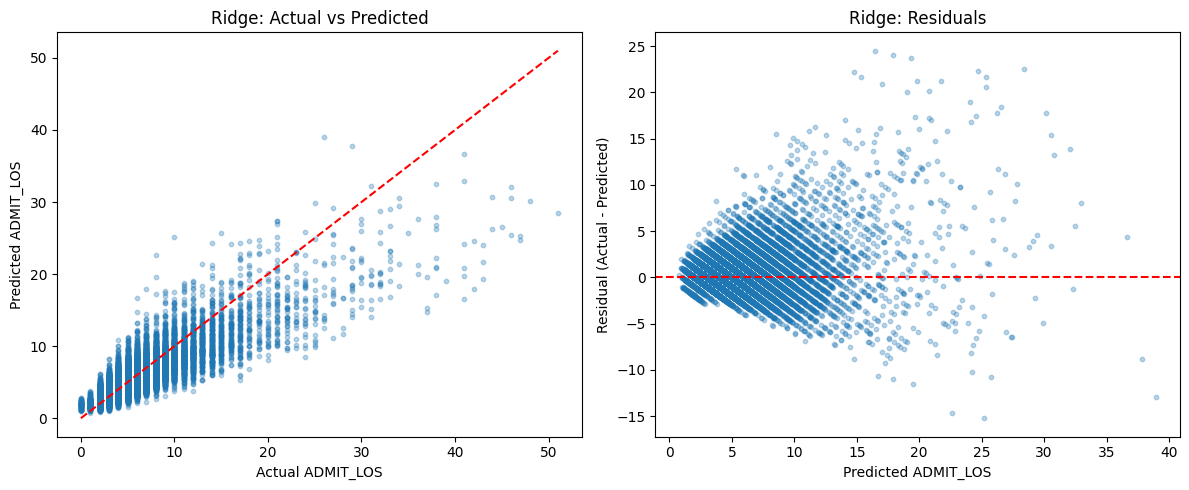

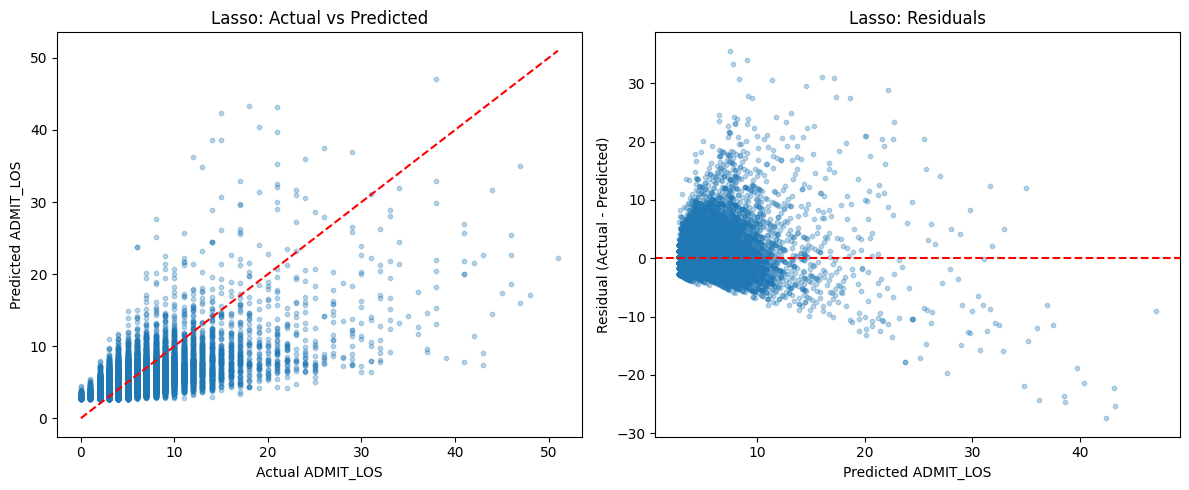

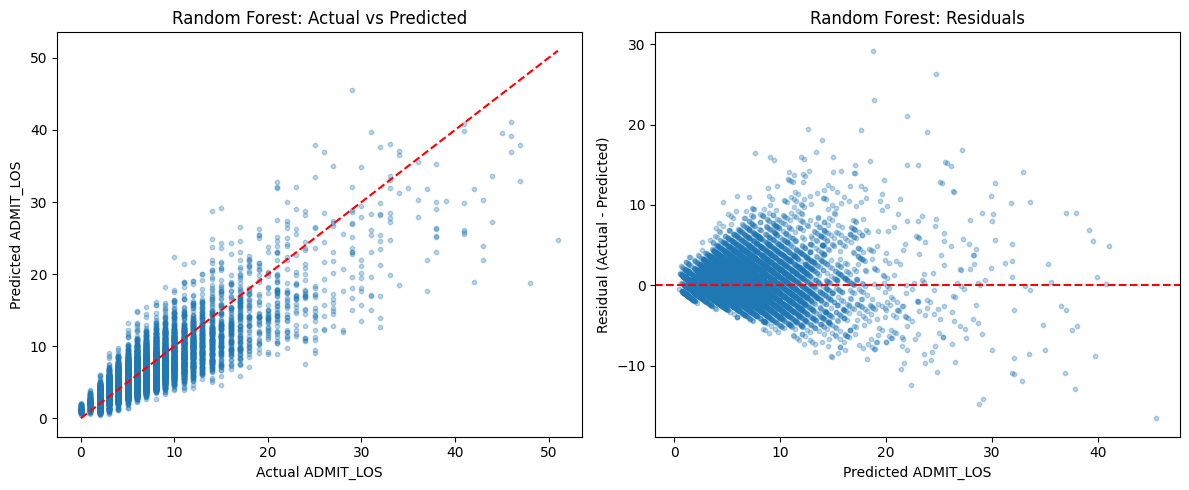

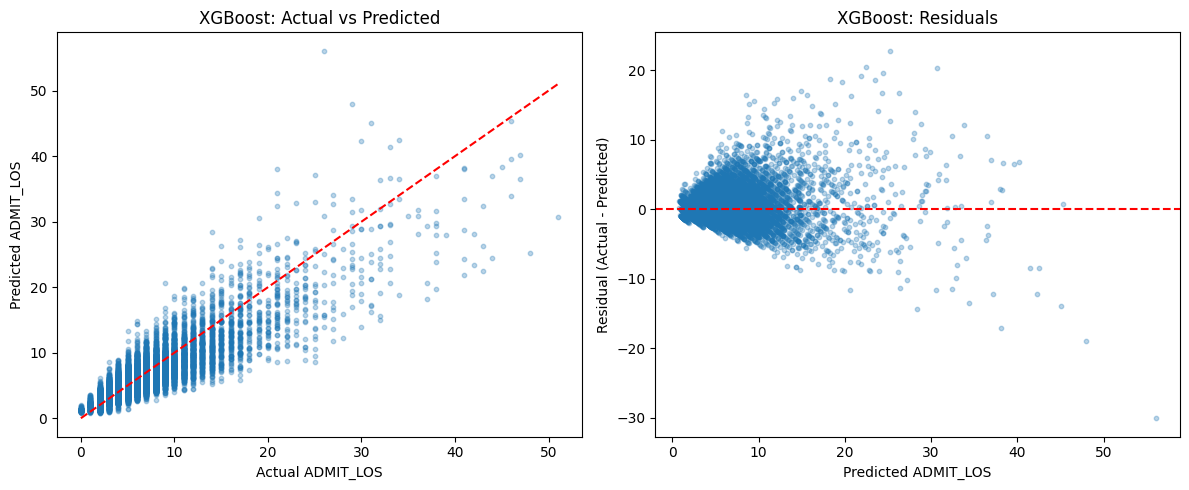

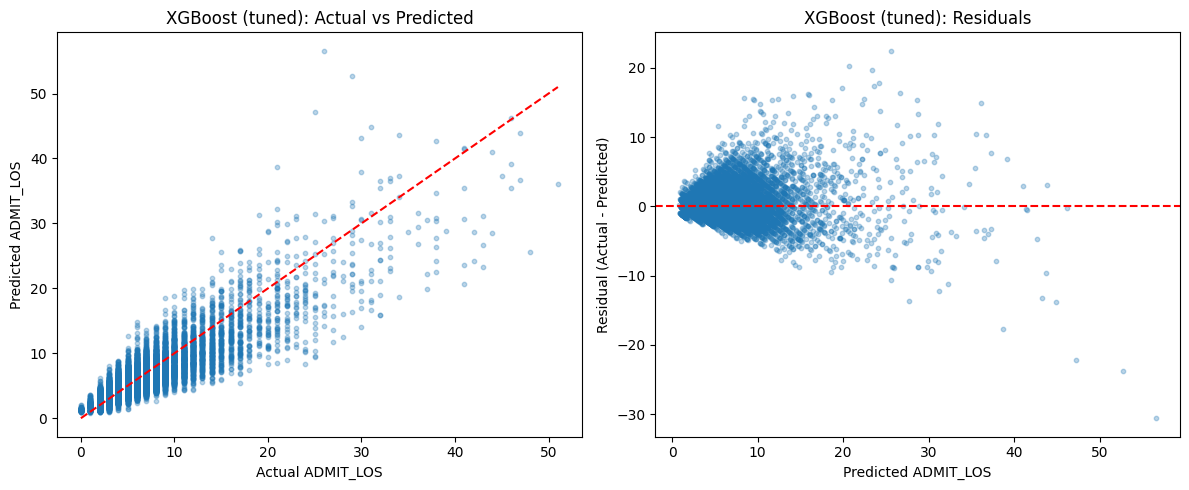

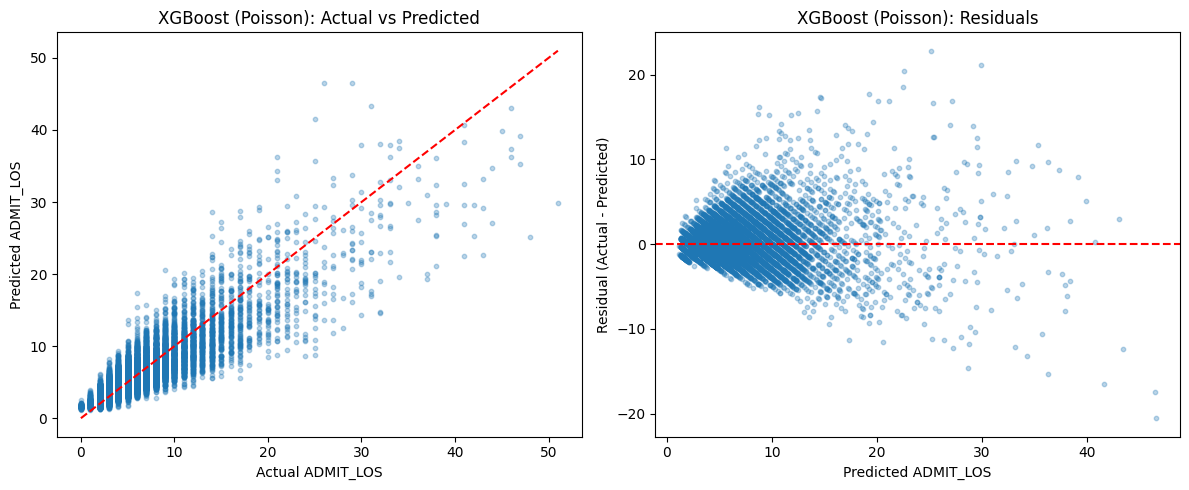

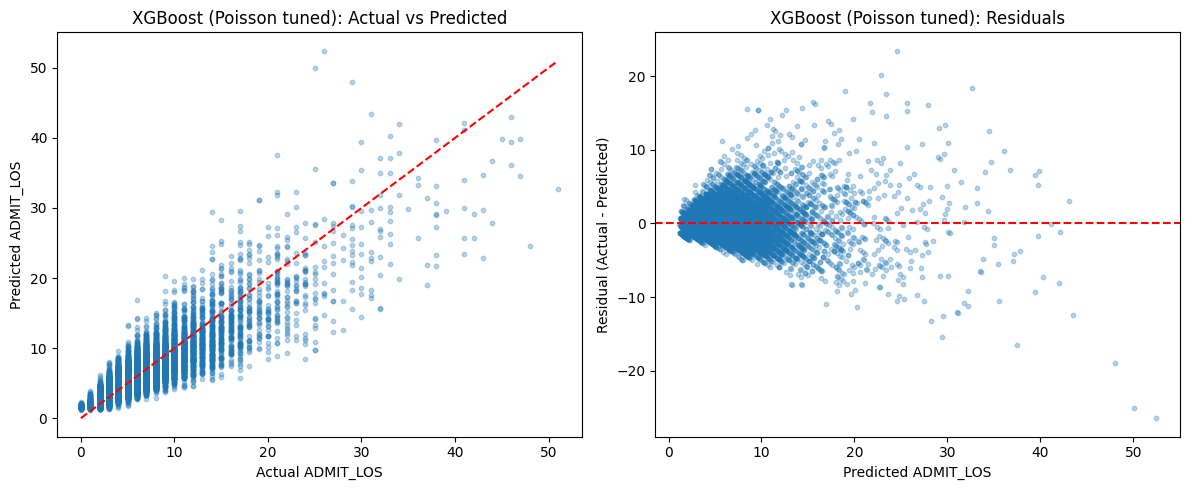

In [104]:
def plot_diagnostics(y_true, y_pred, model_name="model"):
    # Actual vs predicted and residual plots for visual model assessment
    residuals = y_true - y_pred
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(y_true, y_pred, alpha=0.3, s=10)
    axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    axes[0].set_xlabel('Actual ADMIT_LOS')
    axes[0].set_ylabel('Predicted ADMIT_LOS')
    axes[0].set_title(f'{model_name}: Actual vs Predicted')

    axes[1].scatter(y_pred, residuals, alpha=0.3, s=10)
    axes[1].axhline(0, color='r', linestyle='--')
    axes[1].set_xlabel('Predicted ADMIT_LOS')
    axes[1].set_ylabel('Residual (Actual - Predicted)')
    axes[1].set_title(f'{model_name}: Residuals')

    plt.tight_layout()
    plt.show()

plot_diagnostics(y_val_raw, ridge_val_preds, "Ridge")
plot_diagnostics(y_val_raw, lasso_val_preds, "Lasso")
plot_diagnostics(y_val_raw, rf_val_preds, "Random Forest")
plot_diagnostics(y_val_raw, xgb_val_preds, "XGBoost")
plot_diagnostics(y_val_raw, xgb_tuned_val_preds, "XGBoost (tuned)")
plot_diagnostics(y_val_raw, xgb_poisson_val_preds, "XGBoost (Poisson)")
plot_diagnostics(y_val_raw, xgb_poisson_tuned_preds, "XGBoost (Poisson tuned)")

In [106]:
# error-by-LOS-bucket check - confirms whether error concentrates in the long-stay tail
poisson_tuned_residuals = y_val_raw - xgb_poisson_tuned_preds
poisson_tuned_error_df = pd.DataFrame({'actual': y_val_raw, 'abs_error': np.abs(poisson_tuned_residuals)})
print(poisson_tuned_error_df.groupby(pd.cut(poisson_tuned_error_df['actual'], bins=[0, 3, 7, 15, 60]))['abs_error'].mean())

actual
(0, 3]      0.876158
(3, 7]      1.039551
(7, 15]     2.201951
(15, 60]    5.554644
Name: abs_error, dtype: float64


/tmp/ipykernel_21384/3692589802.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(poisson_tuned_error_df.groupby(pd.cut(poisson_tuned_error_df['actual'], bins=[0, 3, 7, 15, 60]))['abs_error'].mean())


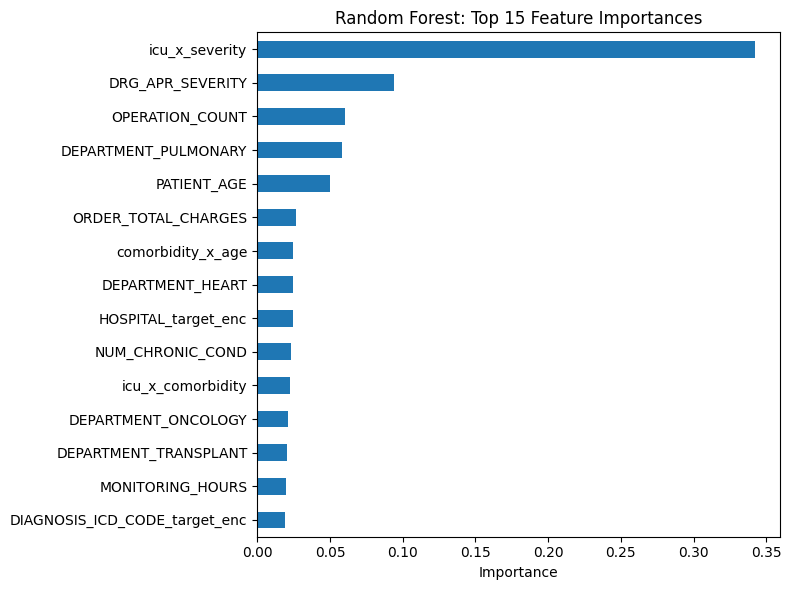

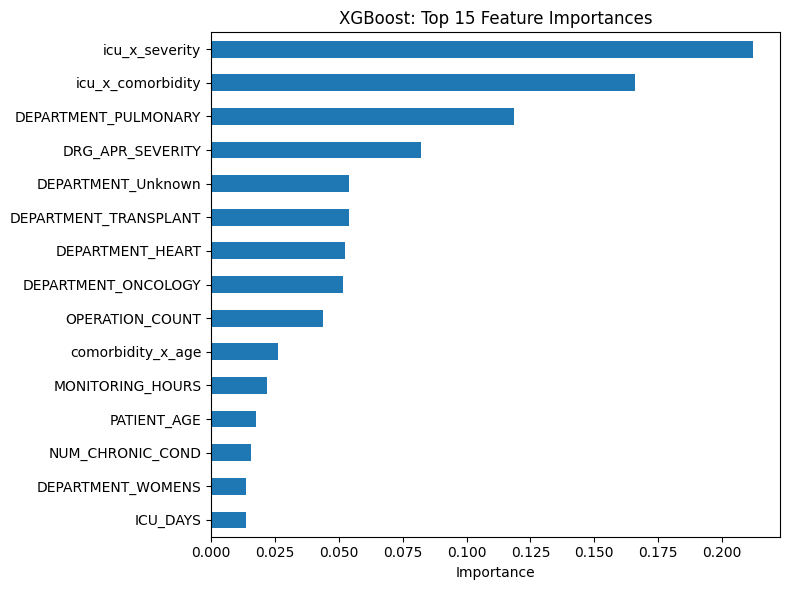

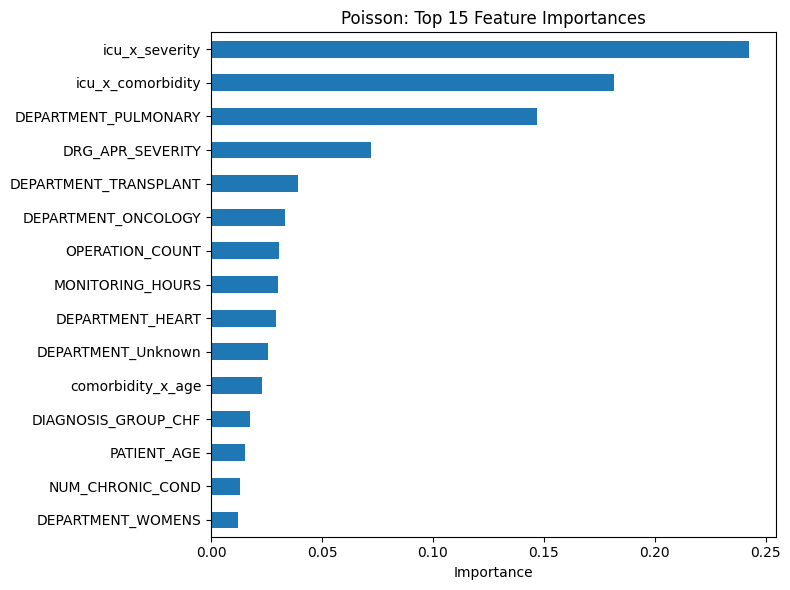

In [107]:
def plot_feature_importance(model, feature_names, model_name="model", top_n=15):
    # Shows top N most influential features for a fitted tree-based model - reference/diagnostic only, not tied to final model selection
    importances = pd.Series(model.feature_importances_, index=feature_names)
    top_features = importances.sort_values(ascending=False).head(top_n)

    plt.figure(figsize=(8, 6))
    top_features.sort_values().plot(kind='barh')
    plt.title(f'{model_name}: Top {top_n} Feature Importances')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

    return top_features

rf_importance = plot_feature_importance(rf_model, X_train.columns, "Random Forest")
xgb_importance = plot_feature_importance(xgb_model, X_train.columns, "XGBoost")
xgb_poisson_importance = plot_feature_importance(xgb_poisson, X_train.columns, "Poisson")


In [108]:
best_model_name = results_df.iloc[0]['model']
print(f"Best model: {best_model_name}")

Best model: XGBoost (Poisson tuned)


In [116]:
# reattach ENCOUNTER_KEY to the data for training
test_original = pd.read_csv('/workspaces/myfolder/project/sasviya_challenge_2026/data/hospital_los_test_transformed.csv')

# confirm the length is the same
print(len(test_original), len(hospital_los_test_final))

# ICU_DAYS wasn't touched by any transformation - if positions match, these should be identical
print((test_original['ICU_DAYS'].values == hospital_los_test_final['ICU_DAYS'].values).all())

15000 15000
True


In [117]:
X_full = hospital_los_train_final.drop(columns=['ADMIT_LOS', 'ADMIT_LOS_log'])
y_full_log = hospital_los_train_final['ADMIT_LOS_log']
y_full_raw = hospital_los_train_final['ADMIT_LOS']

test_encounter_keys = test_original['ENCOUNTER_KEY']
test_features = hospital_los_test_final  # already correctly excludes ENCOUNTER_KEY, PATIENT_NUMBER, etc.

In [118]:
# Map model name to a fresh, untrained instance with its tuned hyperparameters,
# plus which target scale (log vs raw) it needs to be trained on
model_config = {
    'Ridge': {'model': Ridge(alpha=1.0), 'target': 'log'},
    'Lasso': {'model': Lasso(alpha=1.0), 'target': 'log'},
    'Random Forest': {'model': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1), 'target': 'log'},
    'XGBoost': {'model': XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1), 'target': 'log'},
    'XGBoost (tuned)': {'model': XGBRegressor(**xgb_search.best_params_, random_state=42, n_jobs=-1), 'target': 'log'},
    'XGBoost (Poisson)': {'model': XGBRegressor(objective='count:poisson', n_estimators=300, max_depth=6,
                                                  learning_rate=0.05, subsample=0.9, colsample_bytree=0.8,
                                                  min_child_weight=5, random_state=42, n_jobs=-1), 'target': 'raw'},
    'XGBoost (Poisson tuned)': {'model': XGBRegressor(objective='count:poisson', **xgb_poisson_search.best_params_,
                                                        random_state=42, n_jobs=-1), 'target': 'raw'}
}

config = model_config[best_model_name]
final_model = config['model']

if config['target'] == 'log':
    final_model.fit(X_full, y_full_log)
    test_preds_raw = np.expm1(final_model.predict(test_features))
else:
    final_model.fit(X_full, y_full_raw)
    test_preds_raw = final_model.predict(test_features)  # already raw scale, no expm1

test_preds = np.clip(np.round(test_preds_raw), a_min=0, a_max=None)  # no negative/fractional LOS

submission = pd.DataFrame({
    'ENCOUNTER_KEY': test_encounter_keys,
    'ADMIT_LOS': test_preds.astype(int)
})

In [119]:
submission.to_csv('/workspaces/myfolder/project/sasviya_challenge_2026/data/submission_updated.csv', index=False)
print(submission.head())
print(submission.shape)

   ENCOUNTER_KEY  ADMIT_LOS
0      300103958          4
1      300111093          3
2      300102017          4
3      300108959          3
4      300114930          4
(15000, 2)
